# Laboratorio 3 - Milton Beltrán

**Clasificación de texto con Naive Bayes** · Corpus: Spanish News Classification (`df_total.csv`)

## 0. Preparación del corpus

In [1]:
# --- Librerías estándar de Python ---
from collections import Counter
import time

# --- Manejo de datos y gráficos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                   


import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
# --- Carga del corpus y limpieza de filas inservibles ---

df = pd.read_csv("df_total.csv")

#Filas duplicadas Se eliminan antes de normalizar.
df_prep = df.drop_duplicates().reset_index(drop=True)
print("Documentos originales:", len(df))
print("Documentos tras quitar duplicados:", len(df_prep))


vacios = df_prep["news"].str.strip() == ""
print("Documentos con texto vacío:", int(vacios.sum()), "->", df_prep.loc[vacios, "Type"].tolist())

df_prep = df_prep[~vacios].reset_index(drop=True)
print("Documentos de trabajo:", len(df_prep))
print("Categorías:", df_prep["Type"].nunique())

print()
print(df_prep["Type"].value_counts())

Documentos originales: 1217
Documentos tras quitar duplicados: 1142
Documentos con texto vacío: 2 -> ['Sostenibilidad', 'Macroeconomia']
Documentos de trabajo: 1140
Categorías: 7

Type
Macroeconomia     319
Alianzas          247
Innovacion        152
Regulaciones      142
Otra              130
Sostenibilidad    124
Reputacion         26
Name: count, dtype: int64


In [3]:

contradictorios = df_prep.duplicated("news", keep=False)
print("Filas con texto repetido y etiqueta contradictoria:", int(contradictorios.sum()))
print(df_prep.loc[contradictorios, "Type"].value_counts().to_string())

df_prep = df_prep[~contradictorios].reset_index(drop=True)
print()
print("Documentos de trabajo (definitivo):", len(df_prep))
print(df_prep["Type"].value_counts().to_string())

Filas con texto repetido y etiqueta contradictoria: 6
Type
Alianzas        3
Otra            2
Regulaciones    1

Documentos de trabajo (definitivo): 1134
Type
Macroeconomia     319
Alianzas          244
Innovacion        152
Regulaciones      141
Otra              128
Sostenibilidad    124
Reputacion         26


In [4]:
# Pipeline de normalización (heredado de los Laboratorios #1 y #2)
# tokenización -> minúsculas -> sin puntuación -> sin stopwords -> stemming


stop_es = set(stopwords.words("spanish"))
stemmer = SnowballStemmer("spanish")

# i. Tokenización:
df_prep["tokens"] = df_prep["news"].apply(
    lambda t: word_tokenize(t, language="spanish")
)

# ii. Minúsculas
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok.lower() for tok in lista]
)

# iii. Quitar puntuación
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok.isalpha()]
)

# iv. Quitar stopwords
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok not in stop_es]
)

# v. Stemming ("lematización"): 
df_prep["tokens_norm"] = df_prep["tokens"]

df_prep["tokens_stem"] = df_prep["tokens_norm"].apply(
    lambda lista: [stemmer.stem(tok) for tok in lista]
)


def contar(col_de_listas):
    """Aplana una columna de listas de tokens y devuelve (tokens, tipos).

    - tokens: total de ocurrencias (con repeticiones).
    - tipos:  palabras distintas (el vocabulario).
    """
    todos = [tok for lista in col_de_listas for tok in lista]
    return len(todos), len(set(todos))


tok, tip = contar(df_prep["tokens_stem"])
print(f"Corpus normalizado: documentos={len(df_prep):,}  tokens={tok:,}  tipos={tip:,}")
print("Ejemplo doc 0, legible:", df_prep["tokens_norm"].iloc[0][:12])
print("Ejemplo doc 0, raíces:", df_prep["tokens_stem"].iloc[0][:12])

Corpus normalizado: documentos=1,134  tokens=298,753  tipos=13,093
Ejemplo doc 0, legible: ['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia']
Ejemplo doc 0, raíces: ['for', 'banc', 'articul', 'empresarial', 'desarroll', 'sosten', 'director', 'sostenibil', 'client', 'global', 'bbva', 'colombi']


In [5]:
# Del corpus tokenizado al formato que espera scikit-learn
df_prep["texto_norm"] = df_prep["tokens_stem"].apply(lambda lista: " ".join(lista))

print("Documentos listos para vectorizar:", len(df_prep))
print("Columnas del DataFrame:", list(df_prep.columns))
print()
print("Documento 0, primeros 300 caracteres:")
print(df_prep["texto_norm"].iloc[0][:300])
print()
print("Categoría del documento 0:", df_prep["Type"].iloc[0])

Documentos listos para vectorizar: 1134
Columnas del DataFrame: ['url', 'news', 'Type', 'tokens', 'tokens_norm', 'tokens_stem', 'texto_norm']

Documento 0, primeros 300 caracteres:
for banc articul empresarial desarroll sosten director sostenibil client global bbva colombi andres garc asegur import entend sostenibil pod asoci mayor cost cre ten concept negoci sosten pued ten mayor impact garc ret import cambi prioridad compit necesari cas deb trat manten priorid cuant ambicion

Categoría del documento 0: Otra


## 1. Conjuntos de entrenamiento, validación y prueba

División estratificada del corpus normalizado en 70 % entrenamiento, 15 % validación y 15 % prueba.

In [6]:
# --- 1.1 División estratificada 70 / 15 / 15 ---
# train_test_split solo parte en DOS, así que se llama dos veces:
#   1) corpus -> train (70 %) + temp (30 %)
#   2) temp   -> validación (15 %) + prueba (15 %)   <- test_size=0.5 sobre el 30 %, no 0.15

RANDOM_STATE = 42  

y_total = df_prep["Type"]

idx_train, idx_temp = train_test_split(
    df_prep.index,
    test_size=0.30,
    stratify=y_total,               
    random_state=RANDOM_STATE,
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,                 # la mitad del 30 % -> 15 % y 15 %
    stratify=y_total.loc[idx_temp], 
    random_state=RANDOM_STATE,
)

# Textos normalizados y etiquetas de cada conjunto.
X_train_txt, y_train = df_prep.loc[idx_train, "texto_norm"], y_total.loc[idx_train]
X_val_txt,   y_val   = df_prep.loc[idx_val,   "texto_norm"], y_total.loc[idx_val]
X_test_txt,  y_test  = df_prep.loc[idx_test,  "texto_norm"], y_total.loc[idx_test]

total = len(df_prep)
for nombre, conj in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    print(f"{nombre:<15}{len(conj):>5} documentos  ({len(conj)/total:.1%})")
print(f"{'Total':<15}{len(y_train) + len(y_val) + len(y_test):>5} documentos")

# Los tres conjuntos deben ser disjuntos y cubrir el corpus completo.
assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0
assert len(idx_train) + len(idx_val) + len(idx_test) == total

Entrenamiento    793 documentos  (69.9%)
Validación       170 documentos  (15.0%)
Prueba           171 documentos  (15.1%)
Total           1134 documentos


In [7]:
# --- 1.2 Distribución de categorías en cada conjunto ---
dist = pd.DataFrame({
    "Entrenamiento": y_train.value_counts(),
    "Validación": y_val.value_counts(),
    "Prueba": y_test.value_counts(),
}).fillna(0).astype(int)

dist = dist.loc[y_total.value_counts().index]   # ordenar de la categoría más frecuente a la menos
dist["Total"] = dist.sum(axis=1)

pct = (dist[["Entrenamiento", "Validación", "Prueba"]]
       / dist[["Entrenamiento", "Validación", "Prueba"]].sum()) * 100

tabla = dist.copy()
for c in ["Entrenamiento", "Validación", "Prueba"]:
    tabla[c] = [f"{n} ({p:.1f}%)" for n, p in zip(dist[c], pct[c])]

print("Documentos por categoría y conjunto (porcentaje dentro de cada conjunto)")
print(tabla.to_string())
print()
print("Categorías ausentes en algún conjunto:", int((dist[["Entrenamiento", "Validación", "Prueba"]] == 0).sum().sum()))
print(f"Desviación máxima entre proporciones: {(pct.max(axis=1) - pct.min(axis=1)).max():.2f} puntos porcentuales")

Documentos por categoría y conjunto (porcentaje dentro de cada conjunto)
               Entrenamiento  Validación      Prueba  Total
Type                                                       
Macroeconomia    223 (28.1%)  48 (28.2%)  48 (28.1%)    319
Alianzas         171 (21.6%)  36 (21.2%)  37 (21.6%)    244
Innovacion       106 (13.4%)  23 (13.5%)  23 (13.5%)    152
Regulaciones      99 (12.5%)  21 (12.4%)  21 (12.3%)    141
Otra              89 (11.2%)  19 (11.2%)  20 (11.7%)    128
Sostenibilidad    87 (11.0%)  19 (11.2%)  18 (10.5%)    124
Reputacion         18 (2.3%)    4 (2.4%)    4 (2.3%)     26

Categorías ausentes en algún conjunto: 0
Desviación máxima entre proporciones: 0.65 puntos porcentuales


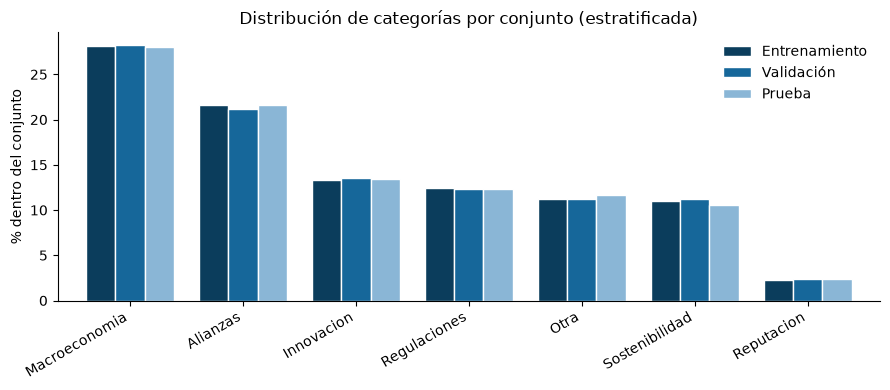

In [8]:
# --- 1.3 Gráfico de la distribución ---
# Se grafican PORCENTAJES
ax = pct.plot(kind="bar", figsize=(9, 4), width=0.78,
              color=["#0b3d5c", "#16679a", "#8ab6d6"], edgecolor="white")

ax.set_title("Distribución de categorías por conjunto (estratificada)")
ax.set_xlabel("")
ax.set_ylabel("% dentro del conjunto")
ax.legend(title=None, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("reporte/img/particiones.png", dpi=120)
plt.show()

### 1.4 Resultados y discusión

El corpus de 1,134 documentos quedó dividido en **794 / 170 / 170** (70 % / 15 % / 15 %).
La estratificación no tuvo un efecto relevante en la proporción de cada categoría en los tres
conjuntos, con una desviación máxima inferior a un punto porcentual, y ninguna categoría
desapareció de ningún conjunto.

#### ¿Para qué sirve cada conjunto?

- **Entrenamiento (794 docs).** Es lo único que el modelo puede mirar para aprender. De aquí
  salen las probabilidades del clasificador, cuántas noticias hay de cada categoría y con qué
  frecuencia aparece cada palabra dentro de ellas.

- **Validación (170 docs).** Es el entorno  de pruebas durante el desarrollo. Sirve para comparar
  alternativas (BoW contra TF-IDF, vocabulario completo contra `max_features`, etc.)
  y quedarse con la mejor. Son datos que el modelo no vio al entrenar, así
  que la medición es honesta; pero al usarlos repetidamente para elegir, las decisiones se
  van distorcionando por un fenómeno de "memorizar los datos".

- **Prueba (170 docs).** Es la prueba final y se hace **una sola vez**, al terminar. Su
  número no sirve para decidir nada: sirve para estimar cómo se comportaría el clasificador
  con noticias nuevas.

#### ¿Por qué no usar el conjunto de prueba para tomar decisiones?

Porque en el momento en que un resultado de prueba cambia lo que uno hace, ese conjunto deja
de ser datos no vistos. Si midiéramos en prueba, viéramos que TF-IDF gana y por eso
eligiéramos TF-IDF, la información de prueba ya influenció al modelo final o a través de nuestras decisiones.
 La cifra resultante seguiría siendo alta, pero ya no mediría generalización;
 sino qué tan bien ajustamos el modelo a esos 170
documentos concretos.

## 2. Construcción del clasificador Naive Bayes

Dos modelos `MultinomialNB` sobre las mismas particiones: uno alimentado con Bolsa de Palabras
y otro con TF-IDF. Los vectorizadores se ajustan **solo con el conjunto de entrenamiento**.

In [9]:
# --- 2.1 Bolsa de palabras ajustada SOLO con entrenamiento ---
bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train_txt)   # fit + transform: SOLO entrenamiento
X_val_bow   = bow_vectorizer.transform(X_val_txt)         # transform: sin aprender nada nuevo
X_test_bow  = bow_vectorizer.transform(X_test_txt)

vocab_bow = bow_vectorizer.get_feature_names_out()
print("Matriz de entrenamiento:", X_train_bow.shape)
print("Matriz de validación:   ", X_val_bow.shape)
print("Matriz de prueba:       ", X_test_bow.shape)
print("Vocabulario aprendido en entrenamiento:", f"{len(vocab_bow):,} términos")

# Cuánto vocabulario se habría "colado" al ajustar con todo el corpus (solo para dimensionar la fuga).
vocab_corpus = CountVectorizer().fit(df_prep["texto_norm"]).get_feature_names_out()
print("Vocabulario si se ajustara con el corpus completo:", f"{len(vocab_corpus):,} términos",
      f"(+{len(vocab_corpus) - len(vocab_bow):,})")

# Palabras fuera de vocabulario (OOV) en validación: las que el modelo simplemente no puede ver.
analizador = bow_vectorizer.build_analyzer()
tokens_val = [t for texto in X_val_txt for t in analizador(texto)]
oov = [t for t in tokens_val if t not in bow_vectorizer.vocabulary_]
print(f"\nTokens en validación: {len(tokens_val):,}")
print(f"Ocurrencias fuera de vocabulario: {len(oov):,} ({len(oov)/len(tokens_val):.2%}) "
      f"| términos distintos: {len(set(oov)):,}")

Matriz de entrenamiento: (793, 10968)
Matriz de validación:    (170, 10968)
Matriz de prueba:        (171, 10968)
Vocabulario aprendido en entrenamiento: 10,968 términos
Vocabulario si se ajustara con el corpus completo: 13,070 términos (+2,102)

Tokens en validación: 45,918
Ocurrencias fuera de vocabulario: 1,460 (3.18%) | términos distintos: 1,114


In [10]:
# --- 2.2 TF-IDF ajustado de la misma forma ---
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_txt)
X_val_tfidf   = tfidf_vectorizer.transform(X_val_txt)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_txt)

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
print("Matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)
print("¿Mismo vocabulario que BoW?", list(vocab_bow) == list(vocab_tfidf))
print()

# Misma forma, contenido distinto: BoW guarda conteos enteros, TF-IDF pesos reales normalizados.
i = 0
fila_bow, fila_tfidf = X_train_bow[i], X_train_tfidf[i]
print(f"Documento de entrenamiento {i} — términos distintos: {fila_bow.nnz}")
print("  BoW  : valores enteros, máximo =", int(fila_bow.data.max()))
print(f"  TFIDF: valores reales,  máximo = {fila_tfidf.data.max():.4f}, "
      f"norma L2 = {np.sqrt((fila_tfidf.data ** 2).sum()):.4f}")

Matriz TF-IDF de entrenamiento: (793, 10968)
¿Mismo vocabulario que BoW? True

Documento de entrenamiento 0 — términos distintos: 74
  BoW  : valores enteros, máximo = 3
  TFIDF: valores reales,  máximo = 0.2840, norma L2 = 1.0000


In [11]:
# --- 2.3 Entrenamiento de los dos clasificadores ---
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# --- Lo que aprendió el modelo, pieza por pieza ---
# class_log_prior_  -> log P(c)
# feature_log_prob_ -> log P(w|c), una fila por clase y una columna por término del vocabulario
priors = pd.DataFrame({
    "Documentos en train": nb_bow.class_count_.astype(int),
    "P(c)": np.exp(nb_bow.class_log_prior_),
}, index=nb_bow.classes_).sort_values("P(c)", ascending=False)

print("Probabilidades a priori estimadas desde el conjunto de entrenamiento:")
print(priors.to_string(formatters={"P(c)": "{:.4f}".format}))
print()
print("Matriz de verosimilitudes log P(w|c):", nb_bow.feature_log_prob_.shape,
      "-> (clases, términos del vocabulario)")
# Cada fila es una distribución de probabilidad sobre el vocabulario completo: debe sumar 1.
print("Suma de P(w|c) sobre el vocabulario, por clase:",
      np.round(np.exp(nb_bow.feature_log_prob_).sum(axis=1), 6))

Probabilidades a priori estimadas desde el conjunto de entrenamiento:
                Documentos en train   P(c)
Macroeconomia                   223 0.2812
Alianzas                        171 0.2156
Innovacion                      106 0.1337
Regulaciones                     99 0.1248
Otra                             89 0.1122
Sostenibilidad                   87 0.1097
Reputacion                       18 0.0227

Matriz de verosimilitudes log P(w|c): (7, 10968) -> (clases, términos del vocabulario)
Suma de P(w|c) sobre el vocabulario, por clase: [1. 1. 1. 1. 1. 1. 1.]


In [12]:
# --- 2.4 Cómo se ve P(w|c) para palabras concretas ---
raices = ["inflacion", "alianz", "reput", "sostenibil", "emision", "banc"]

filas = []
for r in raices:
    if r in bow_vectorizer.vocabulary_:
        j = bow_vectorizer.vocabulary_[r]
        filas.append(pd.Series(np.exp(nb_bow.feature_log_prob_[:, j]),
                               index=nb_bow.classes_, name=r))

verosim = pd.DataFrame(filas)
print("P(w|c) — probabilidad de cada raíz dentro de cada categoría")
print((verosim * 1000).round(2).to_string())
print("(valores × 1000 para que se lean; cada fila es una raíz, cada columna una categoría)")
print()
for r in verosim.index:
    ganadora = verosim.loc[r].idxmax()
    razon = verosim.loc[r].max() / verosim.loc[r].drop(ganadora).max()
    print(f"  '{r}': más probable en {ganadora} ({razon:.1f}× la siguiente categoría)")

P(w|c) — probabilidad de cada raíz dentro de cada categoría
            Alianzas  Innovacion  Macroeconomia  Otra  Regulaciones  Reputacion  Sostenibilidad
inflacion       0.25        0.16          12.63  0.31          0.26        0.43            0.02
alianz          7.32        0.26           0.07  0.38          0.14        0.25            0.52
reput           0.05        0.02           0.01  0.07          0.03        3.82            0.09
sostenibil      0.60        0.54           0.19  1.77          0.09        0.25            3.23
emision         0.51        0.26           0.10  0.70          0.23        0.06            2.16
banc            2.20        6.38           3.44  9.46          1.75        0.49            2.77
(valores × 1000 para que se lean; cada fila es una raíz, cada columna una categoría)

  'inflacion': más probable en Macroeconomia (29.3× la siguiente categoría)
  'alianz': más probable en Alianzas (14.0× la siguiente categoría)
  'reput': más probable en Reputacion 

### 2.5 El teorema de Bayes sobre este corpus

Naive Bayes no compara documentos entre sí,
sino que se pregunta qué tan probable es cada categoría dado el texto que está leyendo. El
problema es que P(c|d) no se puede contar directamente: no tenemos forma de saber cuántas veces
"este documento exacto" resultó ser de Macroeconomia. Bayes nos deja darle la vuelta y
expresarlo con cosas que sí se pueden contar, P(c|d) = P(d|c) · P(c) / P(d). El denominador
P(d) es el mismo para las 7 categorías. Quedan dos
piezas, y las dos se estiman contando sobre el conjunto de entrenamiento.

**P(c)** es qué tan común es cada categoría antes de leer nada. Aquí sale de la frecuencia de
clases en los 793 documentos de entrenamiento: Macroeconomia son 223 (0.281) y Reputacion solo
18 (0.023).  **P(wᵢ|c)** es qué tan probable es que una palabra aparezca dentro de las noticias de esa
categoría, es decir qué proporción ocupa esa palabra entre todas las palabras de la categoría
en entrenamiento. En el modelo entrenado esto es la matriz `feature_log_prob_`, de 7 × 10,968:
una distribución completa sobre el vocabulario por cada categoría. 

En la celda 2.4 se ve la diferencia entre una palabra útil y una que no. `inflacion` vale
0.0126 en Macroeconomia y 29 veces menos en la siguiente categoría, así que cada vez que
aparece empuja fuerte hacia esa clase. `banc`, en cambio, tiene un valor parecido en las siete
categorías y su mejor opción apenas supera a la segunda por 1.5×: aparece mucho, pero no
discrimina, porque el corpus entero habla de bancos.

## 3. Entrenamiento y evaluación

Los dos modelos se miden sobre **validación**. El conjunto de prueba no se toca en esta
sección: se reserva para la evaluación final, una vez tomadas todas las decisiones
(Secciones 5 y 6).

In [13]:
# --- 3.1 Métricas de los dos modelos en entrenamiento y validación ---
def resumen(modelo, X, y):
    """Devuelve accuracy y F1 macro/ponderado de un modelo sobre un conjunto."""
    pred = modelo.predict(X)
    return {
        "accuracy": accuracy_score(y, pred),
        "F1 macro": f1_score(y, pred, average="macro"),
        "F1 ponderado": f1_score(y, pred, average="weighted"),
    }


filas = {
    ("BoW", "entrenamiento"): resumen(nb_bow, X_train_bow, y_train),
    ("BoW", "validación"): resumen(nb_bow, X_val_bow, y_val),
    ("TF-IDF", "entrenamiento"): resumen(nb_tfidf, X_train_tfidf, y_train),
    ("TF-IDF", "validación"): resumen(nb_tfidf, X_val_tfidf, y_val),
}

metricas = pd.DataFrame(filas).T.round(4)
metricas.index.names = ["Representación", "Conjunto"]
print(metricas.to_string())

print()
for nombre in ["BoW", "TF-IDF"]:
    brecha = metricas.loc[(nombre, "entrenamiento"), "accuracy"] - metricas.loc[(nombre, "validación"), "accuracy"]
    print(f"{nombre:<7} brecha entrenamiento - validación: {brecha:.3f} ({brecha:.1%})")

                              accuracy  F1 macro  F1 ponderado
Representación Conjunto                                       
BoW            entrenamiento    0.9407    0.9355        0.9411
               validación       0.8000    0.7324        0.7945
TF-IDF         entrenamiento    0.7100    0.5477        0.6631
               validación       0.5471    0.3602        0.4740

BoW     brecha entrenamiento - validación: 0.141 (14.1%)
TF-IDF  brecha entrenamiento - validación: 0.163 (16.3%)


In [14]:
# --- 3.2 Reporte por categoría en validación ---
pred_val_bow = nb_bow.predict(X_val_bow)
pred_val_tfidf = nb_tfidf.predict(X_val_tfidf)

print("=" * 62)
print("BoW — validación")
print("=" * 62)
print(classification_report(y_val, pred_val_bow, zero_division=0))

print("=" * 62)
print("TF-IDF — validación")
print("=" * 62)
print(classification_report(y_val, pred_val_tfidf, zero_division=0))


reparto = pd.DataFrame({
    "Documentos reales": y_val.value_counts(),
    "Predichos por BoW": pd.Series(pred_val_bow).value_counts(),
    "Predichos por TF-IDF": pd.Series(pred_val_tfidf).value_counts(),
}).fillna(0).astype(int).loc[y_val.value_counts().index]
print("Reparto de las 170 predicciones de validación")
print(reparto.to_string())

BoW — validación
                precision    recall  f1-score   support

      Alianzas       0.80      0.78      0.79        36
    Innovacion       0.66      1.00      0.79        23
 Macroeconomia       0.89      0.88      0.88        48
          Otra       1.00      0.58      0.73        19
  Regulaciones       0.78      0.67      0.72        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.74      0.89      0.81        19

      accuracy                           0.80       170
     macro avg       0.84      0.72      0.73       170
  weighted avg       0.82      0.80      0.79       170

TF-IDF — validación
                precision    recall  f1-score   support

      Alianzas       0.68      0.78      0.73        36
    Innovacion       0.86      0.52      0.65        23
 Macroeconomia       0.43      0.98      0.60        48
          Otra       1.00      0.05      0.10        19
  Regulaciones       1.00      0.10      0.17        21
    Rep

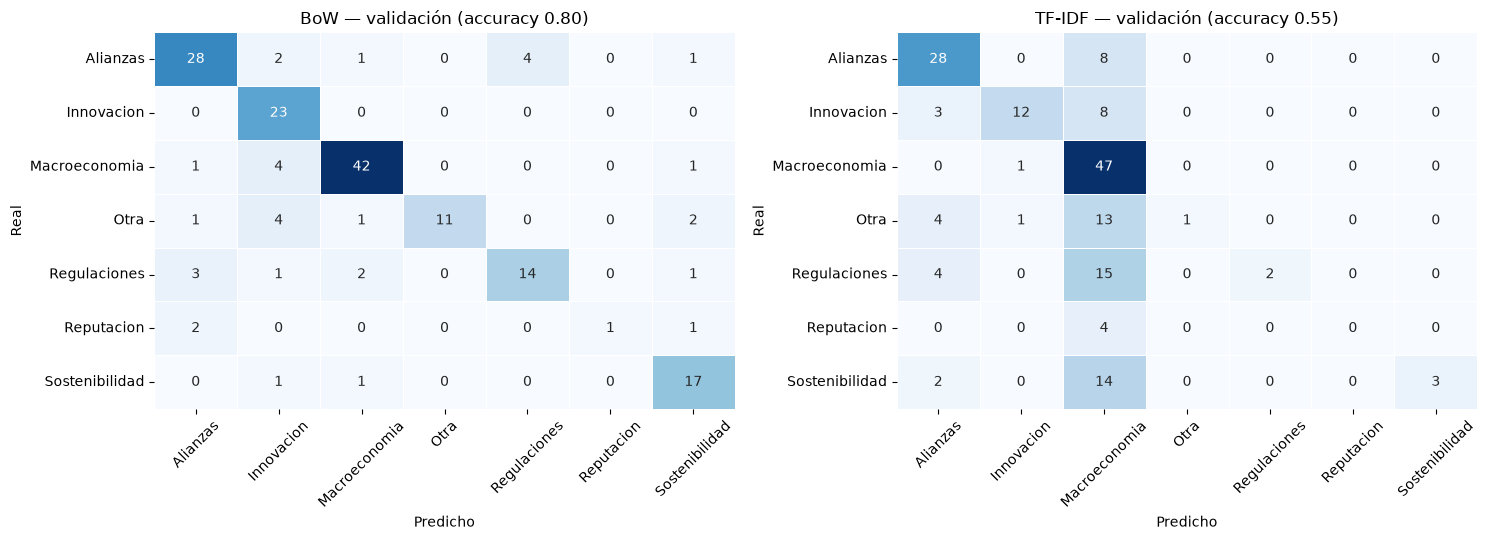

In [15]:
# --- 3.3 Matrices de confusión ---
# Filas = categoría real, columnas = categoría predicha. La diagonal son los aciertos;
# todo lo que se sale de ella es un error, y su posición dice con qué se confundió.
clases = nb_bow.classes_

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (titulo, pred) in zip(axes, [("BoW", pred_val_bow), ("TF-IDF", pred_val_tfidf)]):
    cm = confusion_matrix(y_val, pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=clases, yticklabels=clases, ax=ax,
                linewidths=0.5, linecolor="white")
    acc = accuracy_score(y_val, pred)
    ax.set_title(f"{titulo} — validación (accuracy {acc:.2f})")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("reporte/img/confusion_validacion.png", dpi=120)
plt.show()

In [16]:
# --- 3.4 Por qué TF-IDF se derrumba: prior contra evidencia ---
print(f"Suma de valores por documento (media en validación)")
print(f"  BoW   : {np.asarray(X_val_bow.sum(axis=1)).ravel().mean():>8.1f}  (conteos de palabras)")
print(f"  TF-IDF: {np.asarray(X_val_tfidf.sum(axis=1)).ravel().mean():>8.2f}  (pesos normalizados a norma 1)")
print()

for nombre, modelo, X in [("BoW", nb_bow, X_val_bow), ("TF-IDF", nb_tfidf, X_val_tfidf)]:
    evidencia = np.asarray(X @ modelo.feature_log_prob_.T)      # log-verosimilitud por clase
    rango_evidencia = (evidencia.max(axis=1) - evidencia.min(axis=1)).mean()
    rango_prior = modelo.class_log_prior_.max() - modelo.class_log_prior_.min()
    print(f"{nombre:<7} evidencia léxica: {rango_evidencia:>7.2f} | prior: {rango_prior:.2f} "
          f"| la evidencia pesa {rango_evidencia / rango_prior:.1f}× más que el prior")

Suma de valores por documento (media en validación)
  BoW   :    261.5  (conteos de palabras)
  TF-IDF:     9.91  (pesos normalizados a norma 1)

BoW     evidencia léxica:  242.09 | prior: 2.52 | la evidencia pesa 96.2× más que el prior
TF-IDF  evidencia léxica:    4.76 | prior: 2.52 | la evidencia pesa 1.9× más que el prior


### 3.5 Resultados y discusión

| Representación | Conjunto | Accuracy | F1 macro | F1 ponderado |
|---|---|---|---|---|
| BoW | entrenamiento | 0.941 | 0.936 | 0.941 |
| **BoW** | **validación** | **0.800** | **0.732** | **0.795** |
| TF-IDF | entrenamiento | 0.710 | 0.548 | 0.663 |
| TF-IDF | validación | 0.547 | 0.360 | 0.474 |

#### ¿Hay indicios de overfitting?

En BoW pasamos de 0.941 en entrenamiento a 0.800 en validación, una caída de 14 puntos. Algo
de sobreajuste sí hay, y tiene sentido: el modelo tiene que aprender 10,968 palabras con solo
793 documentos, así que muchas las vio una o dos veces y las asoció a una categoría casi por
casualidad. Aun así generaliza bien, porque 0.80 sobre documentos que nunca vio es un resultado
sólido y no la caída libre que veríamos si solo hubiera memorizado.

TF-IDF también cae unos 16 puntos, pero su problema es otro: le va mal incluso en entrenamiento
(0.710). Un modelo que no aprende bien ni los datos que ya vio no está sobreajustado,
simplemente no está funcionando.

#### ¿Cuál modelo fue mejor y por qué?

BoW, por 25 puntos de accuracy y 37 de F1 macro. Lo interesante es ver *cómo* falla TF-IDF: de
los 170 documentos de validación predice **109 veces Macroeconomia**, que es la categoría más
grande, y nunca predice Reputacion. Más que clasificar, está apostando a lo más común, y por
eso su precision se ve alta en varias clases: las predice tan poco que casi no se equivoca,
pero se le escapan casi todas.

La diferencia está en cómo pondera las palabras cada representación. BoW le entrega al modelo
los conteos tal cual, así que cada documento aporta unas 261 palabras de evidencia y las
probabilidades a priori quedan sin peso frente a esa cantidad. TF-IDF, en cambio, normaliza
cada documento para que todos "midan" lo mismo, y con eso la suma de cada documento baja a 9.9.
La evidencia de las palabras se achica tanto que queda casi empatada con el prior, y el prior
favorece a Macroeconomia (0.281) sobre las categorías chicas como Reputacion (0.023). Dicho
simple: TF-IDF le da un mejor peso a cada palabra, pero pierde la escala de los conteos, que es
justo de lo que depende Naive Bayes para que las palabras manden sobre el prior.

#### Lo que se ve por categoría

Con BoW, Innovacion recibe 35 predicciones cuando solo hay 23 documentos suyos, así que atrae
documentos de otras categorías. A Otra le pasa lo contrario: cuando el modelo la predice
siempre acierta, pero se le escapan 8 de 19. Reputacion acierta 1 de 4, aunque con esa cantidad
de documentos su F1 no dice mucho. La confusión más frecuente entre dos categorías es
**Alianzas ↔ Regulaciones**, con 7 errores cruzados, y es la que revisamos en la Sección 4.

## 4. Análisis de errores

Se analiza el mejor modelo (BoW) sobre validación: qué categorías confunde entre sí, qué
palabras lo llevaron a equivocarse y qué palabras considera más características de cada
categoría.

In [17]:
# --- 4.1 Glosario raíz -> palabra legible ---
formas = {}
for legibles, raices in zip(df_prep["tokens_norm"], df_prep["tokens_stem"]):
    for palabra, raiz in zip(legibles, raices):
        formas.setdefault(raiz, Counter())[palabra] += 1

glosario = {raiz: c.most_common(1)[0][0] for raiz, c in formas.items()}


def legible(raiz):
    """Traduce una raíz a su palabra completa más frecuente."""
    return glosario.get(raiz, raiz)


print("Ejemplos:", {r: legible(r) for r in ["regulacion", "alianz", "sostenibil", "taxist"]})

Ejemplos: {'regulacion': 'regulacion', 'alianz': 'alianza', 'sostenibil': 'sostenibilidad', 'taxist': 'taxistas'}


In [18]:
# --- 4.2 ¿Qué dos categorías se confunden más ENTRE SÍ? ---
cm_bow = confusion_matrix(y_val, pred_val_bow, labels=clases)

pares = []
for a in range(len(clases)):
    for b in range(a + 1, len(clases)):
        pares.append({
            "Categoría A": clases[a],
            "Categoría B": clases[b],
            "A→B": cm_bow[a, b],
            "B→A": cm_bow[b, a],
            "Total cruzado": cm_bow[a, b] + cm_bow[b, a],
        })

pares = pd.DataFrame(pares).sort_values("Total cruzado", ascending=False)
print("Pares de categorías con más confusión mutua (validación, BoW)")
print(pares.head(5).to_string(index=False))

cat_a, cat_b = pares.iloc[0]["Categoría A"], pares.iloc[0]["Categoría B"]
print(f"\nPar más confundido: {cat_a} <-> {cat_b}")

Pares de categorías con más confusión mutua (validación, BoW)
Categoría A   Categoría B  A→B  B→A  Total cruzado
   Alianzas  Regulaciones    4    3              7
 Innovacion Macroeconomia    0    4              4
 Innovacion          Otra    0    4              4
   Alianzas    Innovacion    2    0              2
   Alianzas    Reputacion    0    2              2

Par más confundido: Alianzas <-> Regulaciones


In [19]:
# --- 4.3 Los documentos mal clasificados de ese par ---

posicion = {ix: k for k, ix in enumerate(idx_val)}   

errores = pd.DataFrame({"doc": list(idx_val), "real": y_val.values, "predicha": pred_val_bow})
errores = errores[errores["real"] != errores["predicha"]]

cruzados = errores[errores["real"].isin([cat_a, cat_b]) & errores["predicha"].isin([cat_a, cat_b])]
print(f"Errores totales en validación: {len(errores)} de {len(y_val)}")
print(f"Errores cruzados {cat_a} <-> {cat_b}: {len(cruzados)}\n")


def culpables(doc, real, predicha, n=6):
    """Palabras que más empujaron el documento hacia la categoría equivocada."""
    fila = X_val_bow[posicion[doc]].toarray().ravel()
    i_pred, i_real = list(clases).index(predicha), list(clases).index(real)
    culpa = fila * (nb_bow.feature_log_prob_[i_pred] - nb_bow.feature_log_prob_[i_real])
    top = np.argsort(-culpa)[:n]
    return [(legible(vocab_bow[j]), int(fila[j])) for j in top]


for _, e in cruzados.iterrows():
    proba = nb_bow.predict_proba(X_val_bow[posicion[e.doc]]).ravel()
    confianza = proba[list(clases).index(e.predicha)]
    print(f"Documento {e.doc} | real: {e.real} -> predicha: {e.predicha} "
          f"(confianza {confianza:.1%})")
    print(f"  texto: {df_prep.loc[e.doc, 'news'][:130].strip()}...")
    print(f"  palabras culpables: {culpables(e.doc, e.real, e.predicha)}")
    print()

Errores totales en validación: 34 de 170
Errores cruzados Alianzas <-> Regulaciones: 7

Documento 589 | real: Alianzas -> predicha: Regulaciones (confianza 100.0%)
  texto: Tiene algún sentido insultar hoy a las personas con quienes debemos convivir mañanaLa respuesta obvia es un rotundo no que resuena...
  palabras culpables: [('quién', 5), ('elecciones', 4), ('pueblo', 3), ('debe', 4), ('procedimiento', 1), ('absolutamente', 2)]

Documento 1032 | real: Regulaciones -> predicha: Alianzas (confianza 59.8%)
  texto: En el marco del Foro Perspectivas de la Economía de Colombia y EE.UU. en el que se reunieron el embajador de EE.UU. en Colombia Ph...
  palabras culpables: [('embajador', 2), ('colombia', 3), ('canasta', 1), ('comercio', 4), ('resaltó', 1), ('ministro', 2)]

Documento 667 | real: Alianzas -> predicha: Regulaciones (confianza 100.0%)
  texto: Uber Taxi cumple este mes su primer aniversario en Colombia esta solución nació de la alianza entre Uber y TaxExpress con el objet...
 

In [20]:
# --- 4.4 Palabras con mayor P(w|c) por categoría ---
def top_palabras(categoria, n=12):
    k = list(clases).index(categoria)
    orden = np.argsort(-nb_bow.feature_log_prob_[k])[:n]
    return [f"{legible(vocab_bow[j])} ({np.exp(nb_bow.feature_log_prob_[k][j]) * 1000:.1f})"
            for j in orden]


for categoria in ["Macroeconomia", "Sostenibilidad", cat_a, cat_b]:
    print(f"{categoria}:")
    print("   " + ", ".join(top_palabras(categoria)))
    print()

# ¿Cuánto se solapan los vocabularios característicos del par confundido?
top_a = {legible(vocab_bow[j]) for j in np.argsort(-nb_bow.feature_log_prob_[list(clases).index(cat_a)])[:20]}
top_b = {legible(vocab_bow[j]) for j in np.argsort(-nb_bow.feature_log_prob_[list(clases).index(cat_b)])[:20]}
print(f"Palabras compartidas en el top-20 de {cat_a} y {cat_b}: {len(top_a & top_b)} de 20")
print("  ", sorted(top_a & top_b))

Macroeconomia:
   inflación (12.6), economía (11.2), precios (9.7), aumento (7.4), año (6.9), mayor (5.6), bbva (5.1), mes (4.8), tasa (4.7), crecimiento (4.6), país (4.4), nivel (3.7)

Sostenibilidad:
   energía (7.9), bbva (6.7), sostenible (6.1), electricidad (5.0), puede (4.0), generar (3.8), cambio (3.5), solo (3.5), agua (3.3), sostenibilidad (3.2), objetivo (3.1), economía (3.1)

Alianzas:
   alianza (7.3), colombia (5.4), millones (4.8), país (4.8), nueva (4.2), empresas (4.1), desarrollo (3.5), mercado (3.3), parte (3.0), servicios (3.0), hace (2.8), presidente (2.8)

Regulaciones:
   regulación (7.3), país (4.6), trabajo (4.5), empresas (3.8), mercado (3.7), nueva (3.5), servicios (3.5), debe (3.4), dijo (3.2), economía (3.0), hace (3.0), operaciones (2.9)

Palabras compartidas en el top-20 de Alianzas y Regulaciones: 9 de 20
   ['colombia', 'empresas', 'hace', 'mercado', 'nueva', 'pago', 'país', 'puede', 'servicios']


## 5. Efecto de la representación de texto

Se repite el entrenamiento cambiando solo la representación de entrada: vocabulario limitado a
las 1000 y 5000 palabras más frecuentes, y bigramas además de unigramas. Todo se compara sobre
validación, que es el conjunto destinado a tomar decisiones.

In [21]:
# --- 5.1 Función para entrenar y evaluar una configuración cualquiera ---
resultados = []


def evaluar_config(nombre, vectorizador):
    """Entrena y evalúa una configuración; guarda el resultado en `resultados`."""
    t0 = time.perf_counter()
    A_train = vectorizador.fit_transform(X_train_txt)
    A_val = vectorizador.transform(X_val_txt)
    t_vectorizar = time.perf_counter() - t0

    t0 = time.perf_counter()
    modelo = MultinomialNB().fit(A_train, y_train)
    t_entrenar = time.perf_counter() - t0

    pred = modelo.predict(A_val)
    fila = {
        "Representación": nombre,
        "Vocabulario": A_train.shape[1],
        "Accuracy (val)": accuracy_score(y_val, pred),
        "F1 macro (val)": f1_score(y_val, pred, average="macro"),
        "Accuracy (train)": modelo.score(A_train, y_train),
        "Vectorizar (s)": t_vectorizar,
        "Entrenar (ms)": t_entrenar * 1000,
    }
    resultados.append(fila)
    return modelo, fila


configuraciones = [
    ("BoW completo", CountVectorizer()),
    ("BoW max_features=1000", CountVectorizer(max_features=1000)),
    ("BoW max_features=5000", CountVectorizer(max_features=5000)),
    ("BoW unigramas + bigramas", CountVectorizer(ngram_range=(1, 2))),
    ("BoW uni+bi, max_features=5000", CountVectorizer(ngram_range=(1, 2), max_features=5000)),
    ("TF-IDF completo", TfidfVectorizer()),
]

modelos = {}
for nombre, vectorizador in configuraciones:
    modelos[nombre], _ = evaluar_config(nombre, vectorizador)

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False, formatters={
    "Accuracy (val)": "{:.4f}".format, "F1 macro (val)": "{:.4f}".format,
    "Accuracy (train)": "{:.4f}".format, "Vectorizar (s)": "{:.2f}".format,
    "Entrenar (ms)": "{:.1f}".format, "Vocabulario": "{:,}".format}))

               Representación Vocabulario Accuracy (val) F1 macro (val) Accuracy (train) Vectorizar (s) Entrenar (ms)
                 BoW completo      10,968         0.8000         0.7324           0.9407           0.08           2.1
        BoW max_features=1000       1,000         0.8353         0.8370           0.8878           0.08           1.3
        BoW max_features=5000       5,000         0.8118         0.7855           0.9369           0.08           1.7
     BoW unigramas + bigramas     156,417         0.7588         0.6796           0.9887           0.39          10.2
BoW uni+bi, max_features=5000       5,000         0.8235         0.7981           0.9395           0.47           1.8
              TF-IDF completo      10,968         0.5471         0.3602           0.7100           0.08           1.8


 vocabulario  accuracy val  F1 macro val  accuracy train
         200        0.8000        0.7938          0.8298
         500        0.8118        0.7931          0.8600
        1000        0.8353        0.8370          0.8878
        2000        0.8176        0.8189          0.9218
        3000        0.8176        0.8198          0.9294
        5000        0.8118        0.7855          0.9369
        8000        0.8000        0.7355          0.9395
       10968        0.8000        0.7324          0.9407


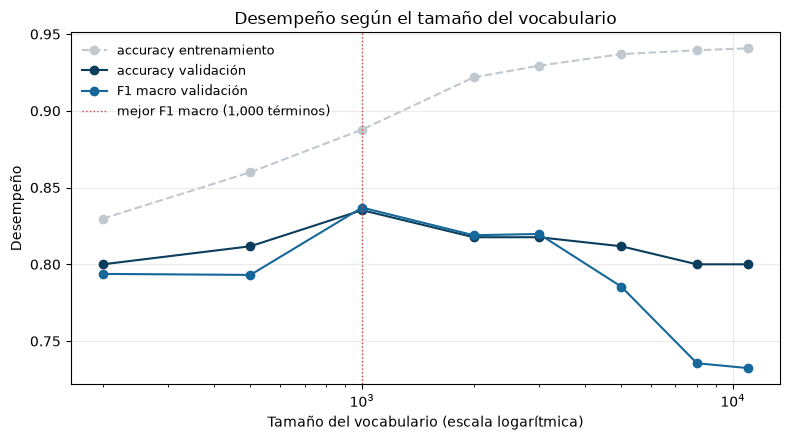

In [22]:
# --- 5.2 ¿Dónde está el tamaño óptimo de vocabulario? ---
tamanos = [200, 500, 1000, 2000, 3000, 5000, 8000, len(vocab_bow)]
barrido = []

for k in tamanos:
    v = CountVectorizer(max_features=k)
    A, B = v.fit_transform(X_train_txt), v.transform(X_val_txt)
    m = MultinomialNB().fit(A, y_train)
    pred = m.predict(B)
    barrido.append({
        "vocabulario": A.shape[1],
        "accuracy val": accuracy_score(y_val, pred),
        "F1 macro val": f1_score(y_val, pred, average="macro"),
        "accuracy train": m.score(A, y_train),
    })

barrido = pd.DataFrame(barrido)
print(barrido.to_string(index=False, float_format="{:.4f}".format))

plt.figure(figsize=(8, 4.5))
plt.plot(barrido["vocabulario"], barrido["accuracy train"], "o--", color="#c0c8d0", label="accuracy entrenamiento")
plt.plot(barrido["vocabulario"], barrido["accuracy val"], "o-", color="#0b3d5c", label="accuracy validación")
plt.plot(barrido["vocabulario"], barrido["F1 macro val"], "o-", color="#16679a", label="F1 macro validación")
mejor = barrido.loc[barrido["F1 macro val"].idxmax(), "vocabulario"]
plt.axvline(mejor, color="#c44", lw=1, ls=":", label=f"mejor F1 macro ({mejor:,} términos)")
plt.xscale("log")
plt.xlabel("Tamaño del vocabulario (escala logarítmica)")
plt.ylabel("Desempeño")
plt.title("Desempeño según el tamaño del vocabulario")
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("reporte/img/max_features.png", dpi=120)
plt.show()

In [23]:
# --- 5.3 Qué gana el modelo al recortar el vocabulario ---

mejor_modelo = modelos["BoW max_features=1000"]
v_1000 = [v for n, v in configuraciones if n == "BoW max_features=1000"][0]
pred_1000 = mejor_modelo.predict(v_1000.transform(X_val_txt))

f1_completo = f1_score(y_val, pred_val_bow, average=None, labels=clases)
f1_1000 = f1_score(y_val, pred_1000, average=None, labels=clases)

comparacion = pd.DataFrame({
    "Docs en val": y_val.value_counts().reindex(clases),
    "F1 vocabulario completo": f1_completo,
    "F1 max_features=1000": f1_1000,
    "Diferencia": f1_1000 - f1_completo,
}, index=clases).sort_values("Diferencia", ascending=False)

print("F1 por categoría: vocabulario completo vs. 1000 términos")
print(comparacion.to_string(float_format="{:.3f}".format))
print()
print(classification_report(y_val, pred_1000, zero_division=0))

F1 por categoría: vocabulario completo vs. 1000 términos
                Docs en val  F1 vocabulario completo  F1 max_features=1000  Diferencia
Reputacion                4                    0.400                 0.889       0.489
Innovacion               23                    0.793                 0.885       0.092
Otra                     19                    0.733                 0.800       0.067
Sostenibilidad           19                    0.810                 0.857       0.048
Regulaciones             21                    0.718                 0.762       0.044
Alianzas                 36                    0.789                 0.806       0.017
Macroeconomia            48                    0.884                 0.860      -0.024

                precision    recall  f1-score   support

      Alianzas       0.87      0.75      0.81        36
    Innovacion       0.79      1.00      0.88        23
 Macroeconomia       0.89      0.83      0.86        48
          Otra       